In [38]:
system_prompt = None

if not system_prompt:
    with open("label-prompt.md", "r") as f:
        system_prompt = f.read()

print(system_prompt[:500])

Your Role: Expert Rhetorical Analyst specializing in persuasion theory and discourse classification.

Short basic instruction:
Classify a short text span according to the single most dominant persuasion technique.

What you should do:
Given a sentence or short span of text, assign exactly ONE label from the following set:

- Ethos
- Pathos
- Logos
- Social_Proof_Identity
- Rhetorical_Patterning
- Neutral

Then provide a brief justification explaining why this technique is dominant over the other


In [39]:
import pandas as pd

df = pd.read_csv("data/conexao_politica_sentences.csv", sep="|")
print(df.shape)
df.head()

(18364, 2)


,id,sentence
0,CNXP-opiniao-20250712-a1983d80-0,O presidente Luiz Inácio Lula da Silva (PT) mi...
1,CNXP-opiniao-20250712-a1983d80-1,"Em nova fala sobre o assunto, ele criticou a d..."
2,CNXP-opiniao-20250712-a1983d80-2,"Durante cerimônia no Espírito Santo, Lula afir..."
3,CNXP-opiniao-20250712-a1983d80-3,“Eu não me conformo que o gás de cozinha sai d...
4,CNXP-opiniao-20250712-a1983d80-4,"Alguém tem que me explicar”, disse o president..."


In [40]:
# keep sentences that have 32+ words
# as a test
df["num_words"] = df["sentence"].apply(lambda x: len(x.split()))
df = df[df["num_words"] >= 32]
df = df.drop(columns=["num_words"])

print(df.shape)

df.head()

(3636, 2)


,id,sentence
4,CNXP-opiniao-20250712-a1983d80-4,"Alguém tem que me explicar”, disse o president..."
11,CNXP-opiniao-20250712-a1983d80-11,O governo federal já mantém o programa Auxílio...
109,CNXP-opiniao-20250512-d13c5d51-12,"Já Eunice e Lóide, mãe e avó de Timóteo, deixa..."
124,CNXP-opiniao-20250512-d13c5d51-27,"A mulher virtuosa, descrita em Provérbios 31, ..."
127,CNXP-opiniao-20250512-d13c5d51-30,"Que nossos filhos possam, no futuro, dizer com..."


In [ ]:
from agno.agent import Agent
from agno.models.openai import OpenAIChat
from pydantic import BaseModel, Field
from typing import List
import asyncio
from tqdm.asyncio import tqdm_asyncio
from dotenv import load_dotenv
import os

load_dotenv()

# Define structured output model
class SentenceLabel(BaseModel):
    label: str = Field(..., description="The classification label for the sentence")
    justification: str = Field(..., description="Brief justification for the classification")

# Configure the model with cost optimizations
model = OpenAIChat(
    id="gpt-4.1-nano",  # Cheaper and faster model
    temperature=0.1,   # Low temperature for consistency
    max_tokens=150,    # Enough for label + justification
)

# Create the agent with the system prompt and structured output
agent = Agent(
    model=model,
    instructions=system_prompt,
    markdown=False,
    output_schema=SentenceLabel,  # Forces structured output
)

# Function to process a sentence (synchronous)
def label_sentence(sentence: str) -> SentenceLabel:
    """Processes a sentence and returns structured label + justification."""
    try:
        response = agent.run(sentence, stream=False)
        # response.content will be a SentenceLabel object
        return response.content
    except Exception as e:
        print(f"Error processing: {e}")
        return SentenceLabel(label="ERROR", justification=str(e))

# Process in concurrent batches for maximum efficiency
async def process_batch(sentences: List[str], batch_size: int = 10) -> List[SentenceLabel]:
    """Processes sentences in concurrent batches."""
    all_labels = []
    
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        # Process batch_size sentences simultaneously in threads
        batch_results = await tqdm_asyncio.gather(
            *[asyncio.to_thread(label_sentence, s) for s in batch],
            desc=f"Processing batch {i//batch_size + 1}"
        )
        all_labels.extend(batch_results)
    
    return all_labels


In [35]:
sample_df = df.head(5).copy()

# Processar o dataframe
sentences = sample_df["sentence"].tolist()

# Execute o processamento
sentence_labels = await process_batch(sentences, batch_size=5)

# Adicione os labels ao dataframe
sample_df["label"] = [label.label for label in sentence_labels]
sample_df["justification"] = [label.justification for label in sentence_labels]

print(f"\nProcessadas {len(sentence_labels)} sentenças")
print(f"Distribuição de labels:\n{sample_df['label'].value_counts()}")
sample_df.head()

Processing batch 1: 100%|██████████| 5/5 [00:02<00:00,  2.14it/s]


Processadas 5 sentenças
Distribuição de labels:
label
Ethos      2
Neutral    1
Logos      1
Pathos     1
Name: count, dtype: int64


,id,sentence,label,justification
4,CNXP-opiniao-20250712-a1983d80,"Alguém tem que me explicar”, disse o president...",Neutral,The sentence primarily reports a factual event...
11,CNXP-opiniao-20250712-a1983d80,O governo federal já mantém o programa Auxílio...,Logos,The sentence provides factual information abou...
109,CNXP-opiniao-20250512-d13c5d51,"Já Eunice e Lóide, mãe e avó de Timóteo, deixa...",Ethos,The passage references the recognition of a si...
124,CNXP-opiniao-20250512-d13c5d51,"A mulher virtuosa, descrita em Provérbios 31, ...",Ethos,The sentence emphasizes the virtuous woman's m...
127,CNXP-opiniao-20250512-d13c5d51,"Que nossos filhos possam, no futuro, dizer com...",Pathos,The sentence appeals to emotional values and m...


In [37]:
print(sample_df.iloc[3]['sentence'])
print("\nLabel:", sample_df.iloc[3]['label'])
print("Justification:", sample_df.iloc[3]['justification'])

A mulher virtuosa, descrita em Provérbios 31, é chamada de bem-aventurada por seus filhos e louvada por seu marido, não apenas por sua força e diligência, mas por sua coerência de vida e temor a Deus.

Label: Ethos
Justification: The sentence emphasizes the virtuous woman's moral character, reputation, and religious devotion, which serve to establish her credibility and moral authority. It appeals to her moral integrity and divine favor, aligning with Ethos as the primary persuasive technique. The focus on her moral virtues and reverence for God suggests an appeal to her character rather than emotion or logic.


In [42]:
# new sample of 500, lets see how it goes
sample_df = df.sample(500, random_state=42).copy()

sentences = sample_df["sentence"].tolist()

sentence_labels = await process_batch(sentences, batch_size=10)

# Add labels to dataframe
sample_df["label"] = [label.label for label in sentence_labels]
sample_df["justification"] = [label.justification for label in sentence_labels]

sample_df.to_csv("data/test500_labeled_sentences_4.1_nano.csv", index=False, sep="|")

print(f"\nProcessadas {len(sentence_labels)} sentenças")
print(f"Distribuição de labels:\n{sample_df['label'].value_counts()}")
sample_df.head()

Processing batch 50: 100%|██████████| 10/10 [00:02<00:00,  4.55it/s]


Processadas 500 sentenças
Distribuição de labels:
label
Pathos                   183
Ethos                    137
Logos                     71
Neutral                   53
Social_Proof_Identity     38
Rhetorical_Patterning     18
Name: count, dtype: int64


,id,sentence,label,justification
6322,CNXP-opiniao-20200326-db301888-7,"A fortíssima economia americana, com fôlego pa...",Pathos,The sentence appeals to emotional confidence a...
671,CNXP-opiniao-20230211-306add2c-0,O deputado federal Daniel Freitas (PL-SC) está...,Ethos,The sentence emphasizes the involvement of a s...
4416,CNXP-opiniao-20200917-29efef4e-10,O que entendemos é que não se pode substituir ...,Social_Proof_Identity,The sentence emphasizes the consensus of the m...
7560,CNXP-opiniao-20191219-3b8847ad-6,A promotoria fala que a compra foi feita por R...,Logos,The sentence presents a factual correction and...
14704,CNXP-opiniao-20180318-b3364ec0-4,Lembro que minha primeira manifestação nas red...,Pathos,The sentence appeals to emotional outrage over...


## Analyze labels with bigrams

what are the most common bigrams for each label?

In [44]:
# bigram counts for each label
# using bigram lib

# tokenize text from sample_df
from nltk.tokenize import word_tokenize
sample_df["tokens"] = sample_df["sentence"].apply(word_tokenize)
sample_df.head()

# remove stop words and ponctuation to new "tokens_no_stop" column
from nltk.corpus import stopwords
import string

stop_words = set(stopwords.words("portuguese"))
special_chars = ["nbsp", "nbsp;", "nbsp", "nbsp;", "\n", "\t", "'", '"', "`", "``", "''", "“", "”", "‘", "’"]

sample_df["tokens_no_stop"] = sample_df["tokens"].apply(
    lambda tokens: [
        token for token in tokens 
        if (token.lower() not in stop_words)
        and (token not in string.punctuation) 
        and (token.lower() not in special_chars)
    ]
)
sample_df.head()

,id,sentence,label,justification,tokens,tokens_no_stop
6322,CNXP-opiniao-20200326-db301888-7,"A fortíssima economia americana, com fôlego pa...",Pathos,The sentence appeals to emotional confidence a...,"[A, fortíssima, economia, americana, ,, com, f...","[fortíssima, economia, americana, fôlego, muit..."
671,CNXP-opiniao-20230211-306add2c-0,O deputado federal Daniel Freitas (PL-SC) está...,Ethos,The sentence emphasizes the involvement of a s...,"[O, deputado, federal, Daniel, Freitas, (, PL-...","[deputado, federal, Daniel, Freitas, PL-SC, ar..."
4416,CNXP-opiniao-20200917-29efef4e-10,O que entendemos é que não se pode substituir ...,Social_Proof_Identity,The sentence emphasizes the consensus of the m...,"[O, que, entendemos, é, que, não, se, pode, su...","[entendemos, pode, substituir, senso, comum, g..."
7560,CNXP-opiniao-20191219-3b8847ad-6,A promotoria fala que a compra foi feita por R...,Logos,The sentence presents a factual correction and...,"[A, promotoria, fala, que, a, compra, foi, fei...","[promotoria, fala, compra, feita, R, 2,6, milh..."
14704,CNXP-opiniao-20180318-b3364ec0-4,Lembro que minha primeira manifestação nas red...,Pathos,The sentence appeals to emotional outrage over...,"[Lembro, que, minha, primeira, manifestação, n...","[Lembro, primeira, manifestação, redes, gerou,..."


In [46]:
import wordcloud
from collections import Counter

for label in sample_df["label"].unique():
    label_tokens = sample_df[sample_df["label"] == label]["tokens_no_stop"].explode()
    bigrams = list(zip(label_tokens, label_tokens[1:]))
    bigram_counts = Counter(bigrams)
    
    # Get top 20 bigrams
    top_bigrams = bigram_counts.most_common(20)
    
    print(f"\nTop bigrams for label '{label}':")
    for bigram, count in top_bigrams:
        print(f"{bigram}: {count}")


Top bigrams for label 'Pathos':
('Imagem', 'Reprodução'): 4
('muitas', 'vezes'): 4
('pra', 'Pasárgada'): 4
('Congresso', 'Nacional'): 3
('Assim', 'Jesus'): 3
('quase', 'sempre'): 3
('Óscar', 'Pérez'): 3
('Rio', 'Janeiro'): 3
('caption', 'id='): 3
('id=', 'align='): 3
('align=', 'alignnone'): 3
('alignnone', 'width='): 3
('Reprodução', '/caption'): 3
('Jesus', 'disse'): 3
('sob', 'pena'): 3
('Vou-me', 'embora'): 3
('embora', 'pra'): 3
('Bolsa', 'Família'): 2
('Ministro', 'Justiça'): 2
('SÉRIE', 'Dez'): 2

Top bigrams for label 'Ethos':
('notável', 'saber'): 3
('saber', 'jurídico'): 3
('Lava', 'Jato'): 3
('território', 'nacional'): 3
('Jair', 'Bolsonaro'): 3
('Donald', 'Trump'): 3
('Dr.', 'Carlos'): 3
('Segurança', 'Trabalho'): 3
('Boko', 'Haram'): 3
('empresas', 'chinesas'): 3
('deputado', 'federal'): 2
('Desenvolvimento', 'Econômico'): 2
('Presidente', 'República'): 2
('Supremo', 'Tribunal'): 2
('Tribunal', 'Federal'): 2
('Cristiano', 'Zanin'): 2
('todo', 'território'): 2
('Israel', '

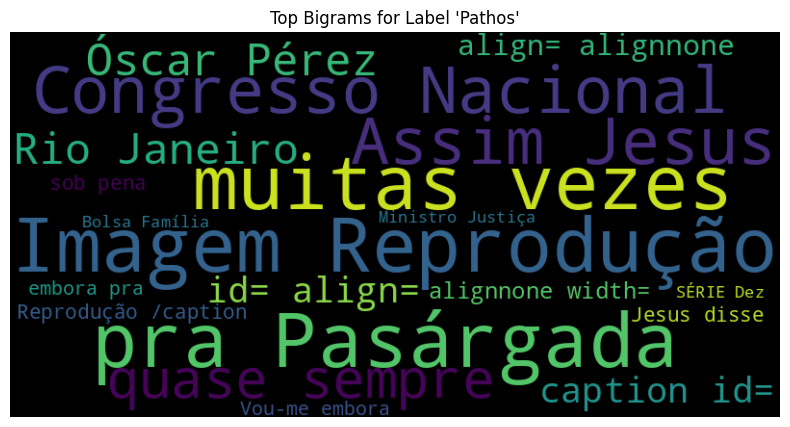

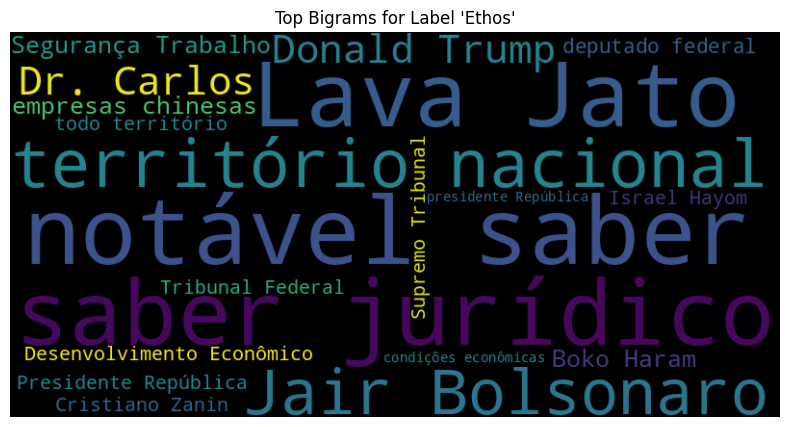

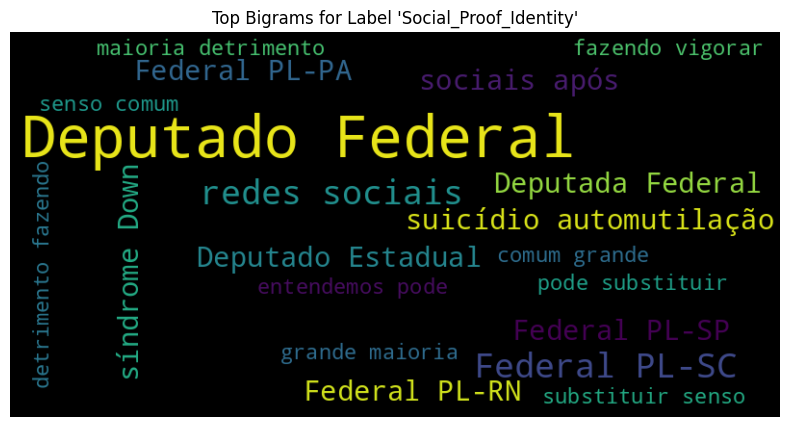

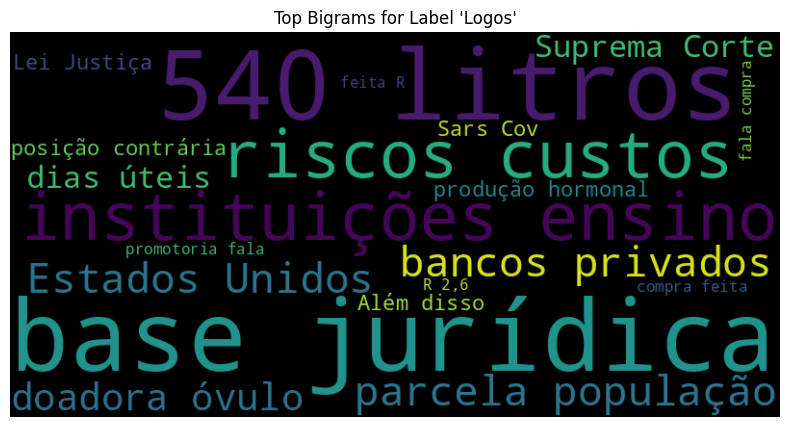

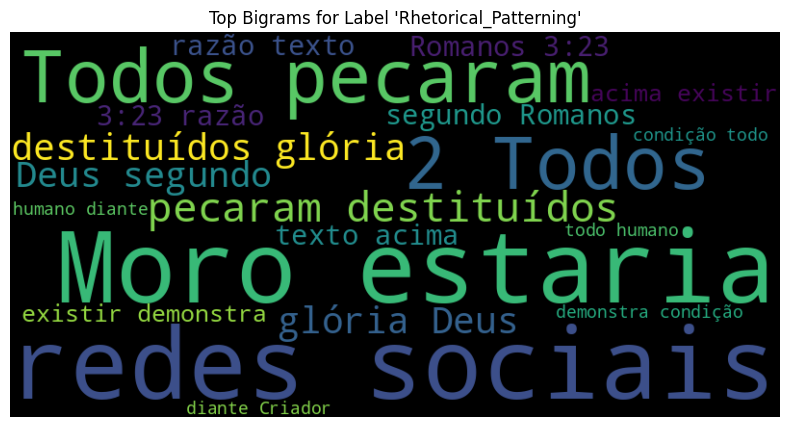

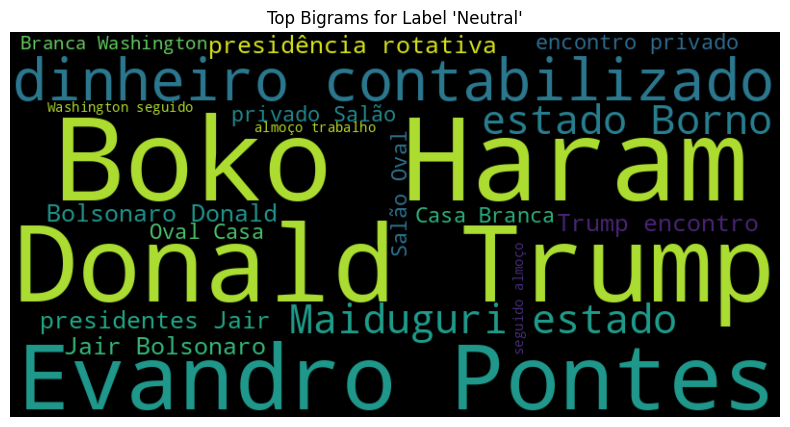

In [47]:
import wordcloud
import matplotlib.pyplot as plt

for label in sample_df["label"].unique():
    label_tokens = sample_df[sample_df["label"] == label]["tokens_no_stop"].explode()
    bigrams = list(zip(label_tokens, label_tokens[1:]))
    bigram_counts = Counter(bigrams)
    
    # Get top 20 bigrams
    top_bigrams = bigram_counts.most_common(20)
    
    # Create a word cloud for bigrams
    bigram_dict = {" ".join(bigram): count for bigram, count in top_bigrams}
    wc = wordcloud.WordCloud(width=800, height=400).generate_from_frequencies(bigram_dict)
    
    # Plot the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Top Bigrams for Label '{label}'")
    plt.show()